# Convolutional Denoising Autoencoder

Train the convolutional autoencoder to reconstruct clean MNIST images from Gaussian-noised inputs.


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

In [2]:
transform = transforms.ToTensor()  # tensor(0.) tensor(1.)

# transform = transforms.Compose([
#     transforms.ToTensor(),
#     transforms.Normalize((0.5), (0.5))
# ])  # -> tensor(-1.) tensor(1.) for tanh activation function

mnist_data = datasets.MNIST(root='./data', train=True, download=True, transform=transform)

data_loader = torch.utils.data.DataLoader(dataset=mnist_data,
                                          batch_size=64,
                                          shuffle=True)

In [3]:
dataiter = iter(data_loader)
images, labels = next(dataiter)
print(torch.min(images), torch.max(images))

tensor(0.) tensor(1.)


In [4]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Reduce the size
        # N(=batch size), 784(=28x28)
        self.encoder = nn.Sequential(
            nn.Linear(28 * 28, 128),  # N, 784 -> N, 128
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 12),
            nn.ReLU(),
            nn.Linear(12, 3)  # -> N, 3
        )

        self.decoder = nn.Sequential(
            # N, 3 -> N, 784

            nn.Linear(3, 12),
            nn.ReLU(),
            nn.Linear(12, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 28 * 28),
            nn.Sigmoid()  # Activation Funciton
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh

In [5]:
class Autoencoder(nn.Module):
    def __init__(self):
        
        super().__init__()
        self.encoder = nn.Sequential(
            # N, 1, 28, 28
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1),  # N, 16, 14, 14
            nn.ReLU(),
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1), # N, 32, 7, 7
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=7) # stride=1, padding=0 # N, 64, 1, 1
        )

        self.decoder = nn.Sequential(
            # N, 64, 1, 1
            nn.ConvTranspose2d(64, 32, 7), # N, 32, 7, 7
            nn.ReLU(),           
            # IMPORTNAT! use output_padding to produce output spatial size 14, not 13
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1), # N, 16, 14, 14
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1), # N, 1, 28, 28
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Note: [-1, 1] -> nn.Tanh
# nn.MaxPool2d <-> nn.MaxUnpool2d

In [6]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if device.type == "cuda":
    print(torch.cuda.get_device_name(0))

noise_mean = 0.0
noise_std = 0.4

model = Autoencoder().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)

Using device: cuda
NVIDIA GeForce RTX 5080


In [7]:
num_epochs = 10
outputs = []

for epoch in range(num_epochs):
    for (img, _) in data_loader:
        img = img.to(device)
        noise = torch.randn_like(img) * noise_std + noise_mean
        noisy_img = torch.clamp(img + noise, 0.0, 1.0)

        recon = model(noisy_img)
        loss = criterion(recon, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f'Epoch:{epoch + 1}, Loss:{loss.item():.4f}')
    outputs.append((
        epoch,
        img.detach().cpu(),
        noisy_img.detach().cpu(),
        recon.detach().cpu(),
    ))  # clean image, noisy image, reconstructed image

Epoch:1, Loss:0.0148
Epoch:2, Loss:0.0117
Epoch:3, Loss:0.0095
Epoch:4, Loss:0.0102
Epoch:5, Loss:0.0101
Epoch:6, Loss:0.0090
Epoch:7, Loss:0.0081
Epoch:8, Loss:0.0083
Epoch:9, Loss:0.0084
Epoch:10, Loss:0.0085


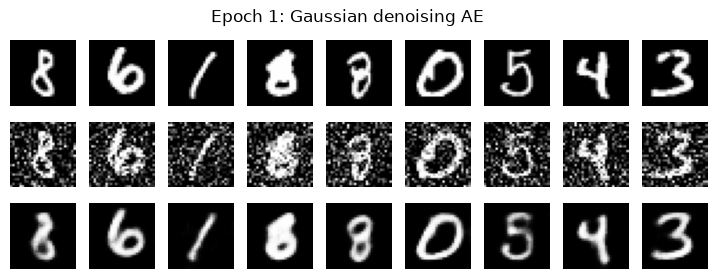

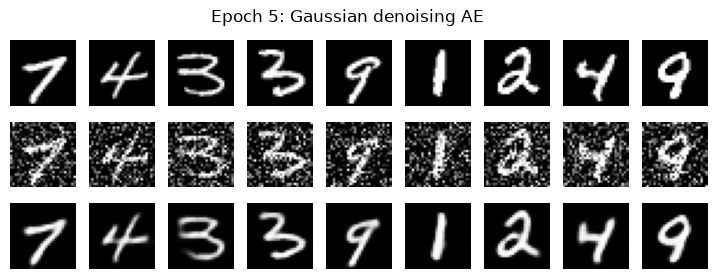

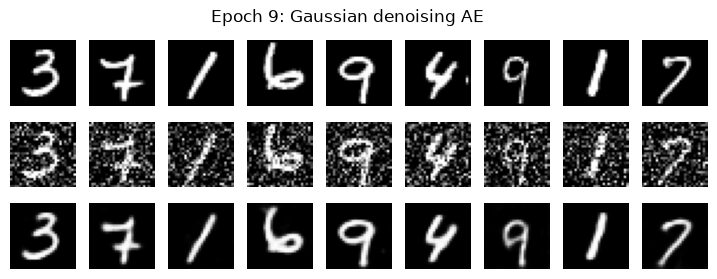

In [8]:
for k in range(0, num_epochs, 4):
    plt.figure(figsize=(9, 3))
    plt.gray()
    clean_imgs = outputs[k][1].numpy()
    noisy_imgs = outputs[k][2].numpy()
    recon = outputs[k][3].numpy()

    rows = [
        ("clean", clean_imgs),
        ("noisy", noisy_imgs),
        ("recon", recon),
    ]

    for row_idx, (name, row_imgs) in enumerate(rows):
        for col_idx, item in enumerate(row_imgs[:9]):
            ax = plt.subplot(3, 9, row_idx * 9 + col_idx + 1)
            ax.imshow(item.reshape(28, 28))
            ax.axis("off")
            if col_idx == 0:
                ax.set_ylabel(name, rotation=0, labelpad=24, va="center")

    plt.suptitle(f"Epoch {outputs[k][0] + 1}: Gaussian denoising AE")
    plt.show()